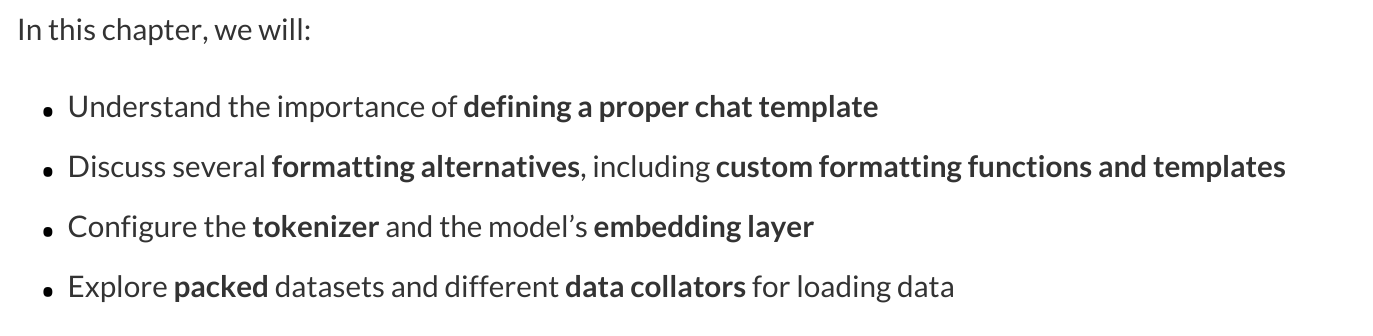

In [2]:
import torch
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    DataCollatorWithPadding,
)

from peft import (
    prepare_model_for_kbit_training,
    get_peft_model,
    LoraConfig
)

from trl import (
    SFTTrainer,
    SFTConfig,
    apply_chat_template,      # replaces setup_chat_format
    pack_dataset,             # replaces ConstantLengthDataset
    get_kbit_device_map,      # bonus: useful for quantization
)

In [3]:
tokenizer = AutoTokenizer.from_pretrained('facebook/opt-350m')
quote = 'A noble spirit embiggens the smallest man.'
print(tokenizer.tokenize(quote))
print(tokenizer.encode(quote, add_special_tokens=False))

['A', 'Ġnoble', 'Ġspirit', 'Ġemb', 'igg', 'ens', 'Ġthe', 'Ġsmallest', 'Ġman', '.']
[250, 25097, 4780, 18484, 11702, 1290, 5, 15654, 313, 4]


In [4]:
# Chapter 2: QLoRA 4-bit quantization setup
supported = torch.cuda.is_bf16_supported(including_emulation=False)
compute_dtype = torch.bfloat16 if supported else torch.float32

nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype
)

model_q4 = AutoModelForCausalLM.from_pretrained(
    "facebook/opt-350m",
    device_map='cuda:0',
    dtype=compute_dtype,
    quantization_config=nf4_config
)

# Chapter 3: Prepare model for k-bit training with LoRA
model_q4 = prepare_model_for_kbit_training(model_q4)

config = LoraConfig(
    r=16,
    lora_alpha=32,
    
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

peft_model = get_peft_model(model_q4, config)

Loading weights: 100%|██████████| 388/388 [00:00<00:00, 507.41it/s]


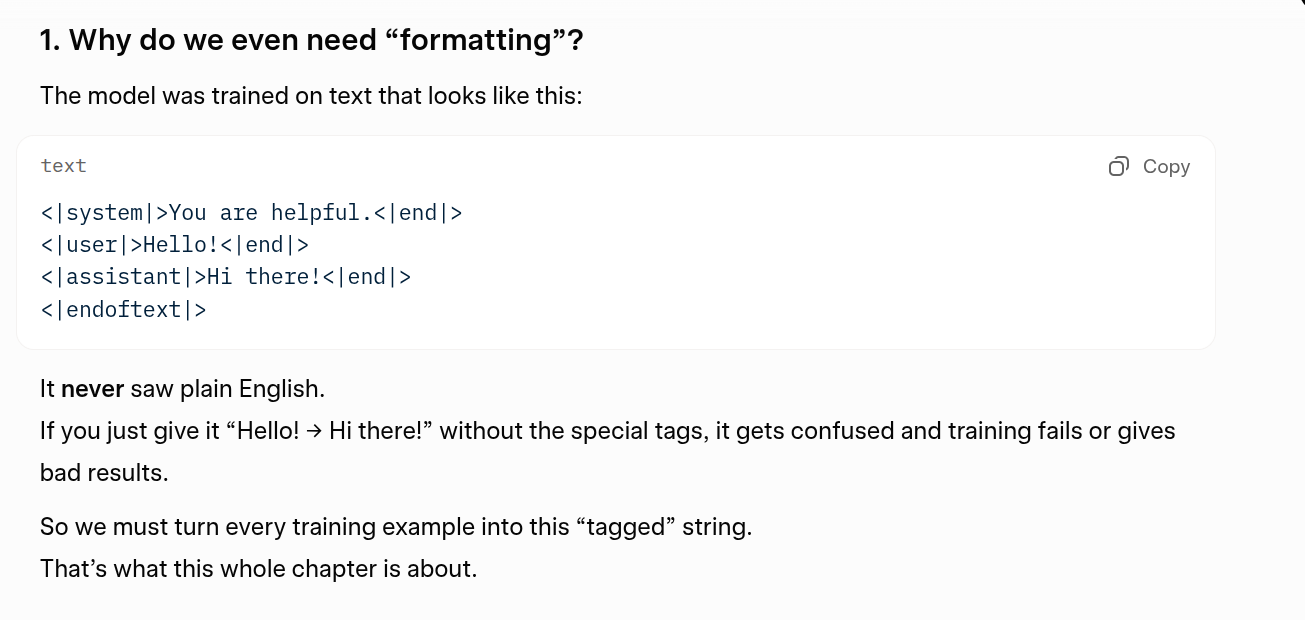

Applying Templates

In [5]:
repo_id = "microsoft/phi-3-mini-4k-instruct"
tokenizer_phi= AutoTokenizer.from_pretrained(repo_id)
print(tokenizer_phi.chat_template)

{% for message in messages %}{% if message['role'] == 'system' %}{{'<|system|>
' + message['content'] + '<|end|>
'}}{% elif message['role'] == 'user' %}{{'<|user|>
' + message['content'] + '<|end|>
'}}{% elif message['role'] == 'assistant' %}{{'<|assistant|>
' + message['content'] + '<|end|>
'}}{% endif %}{% endfor %}{% if add_generation_prompt %}{{ '<|assistant|>
' }}{% else %}{{ eos_token }}{% endif %}


In [6]:
messages = [
{'role': 'system', 'content': 'You are a helpful AI assistant.'},
{'role': 'user', 'content': 'What is 2+2??'},
{'role': 'assistant', 'content': '4.'} ] 



formatted = tokenizer_phi.apply_chat_template(
conversation=messages, tokenize=False, add_generation_prompt=False)


print(formatted)

<|system|>
You are a helpful AI assistant.<|end|>
<|user|>
What is 2+2??<|end|>
<|assistant|>
4.<|end|>
<|endoftext|>


## example 2 : multi turn conversation 

In [21]:
messages = [
    {"role": "system",    "content": "You are helpful."},
    {"role": "user",      "content": "Hi"},
    {"role": "assistant", "content": "Hello!"},
    {"role": "user",      "content": "What is capital of Nepal?"},
    {"role": "assistant", "content": "Kathmandu!"}
]

formatted = tokenizer_phi.apply_chat_template(
conversation=messages, tokenize=False, add_generation_prompt=False)

print((formatted))

<|system|>
You are helpful.<|end|>
<|user|>
Hi<|end|>
<|assistant|>
Hello!<|end|>
<|user|>
What is capital of Nepal?<|end|>
<|assistant|>
Kathmandu!<|end|>
<|endoftext|>


# For later inference when you want the model to answer

### step 1: prepare input  

In [7]:
# Remove the last assistant message 
inference_text = tokenizer_phi.apply_chat_template(
    messages[:-1],  # all messages except the last assistant turn (so model predicts next)
    tokenize=False, 
    add_generation_prompt=True   # inserts special marker like <|assistant|> so model knows it should generate a reply.
)

print(inference_text)

<|system|>
You are a helpful AI assistant.<|end|>
<|user|>
What is 2+2??<|end|>
<|assistant|>



## now model needs to inference

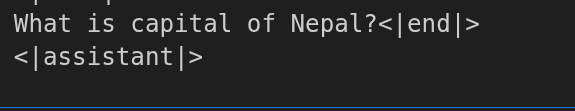

Now you can do model.generate() and the model starts writing after <|assistant|>.

## step 2 : tokenize 

In [11]:
inputs = tokenizer_phi(inference_text, return_tensors="pt").to("cuda")
inputs

{'input_ids': tensor([[32006,   887,   526,   263,  8444,   319, 29902, 20255, 29889, 32007,
         32010,  1724,   338, 29871, 29906, 29974, 29906,  8773, 32007, 32001]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='cuda:0')}

##  step3 : generate

In [9]:
output_ids = peft_model.generate(
    **inputs,
    max_new_tokens=200,       # how long the response can be
    do_sample=True,           # sample tokens (for creativity)
    temperature=0.7,          # randomness
    top_p=0.9,                # nucleus sampling
)

## Step 4: Decode

In [13]:
generated_text = tokenizer_phi.decode(output_ids[0], skip_special_tokens=True)
print(generated_text)

You are a helpful AI assistant. What is 2+2??PA������lick más����� donde changed�� más���ld afTser mKS%ortlink donde changed?ęż más��Neima �����ortresultęż����� donde changed���lick más�������lick más más���lick más������ Notве з�����lick más donde changed���lick más������ Notве з�����lick más�� donde changed���lick más������ Notве з�����lick más donde changed���lick má


## looks like lora doest works well lol  why , because we are using model facebook/opt-350m and but using tokenizer from microsoft/phi-3-mini-4k-instruct

In [14]:
output_ids = model_q4.generate(
    **inputs,
    max_new_tokens=200,       # how long the response can be
    do_sample=True,           # sample tokens (for creativity)
    temperature=0.7,          # randomness
    top_p=0.9,                # nucleus sampling
)


generated_text = tokenizer_phi.decode(output_ids[0], skip_special_tokens=True)
print(generated_text)

[ roseBu DaarR[ roseBu DaarR roseBu DaarR��������� headers��iddleunction[(). Have DaarR


## same problem here , different tokenizer and different model so  output is kinds messeed up

# Supported Formats

the trainer classes (SFTTrainer ) 
supports two formats natively for llm training

# 1) conversational:

the feature should be named either messages or conversations, and it must contain a list
of dictionaries with both role and content keys:

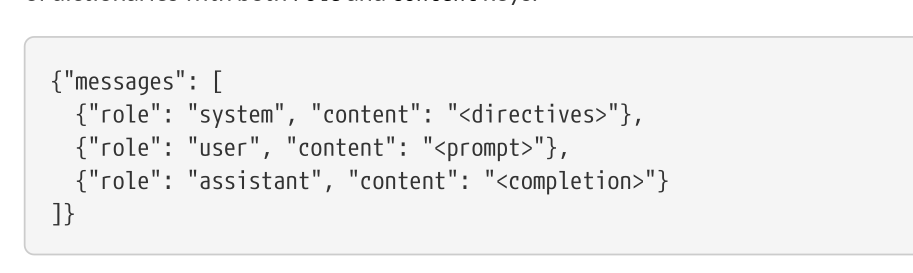

# 2 instruction:

the dataset must contain two features, prompt and completion, representing the contents of
the user and the assistant, respectively (there can be no system role in this format):

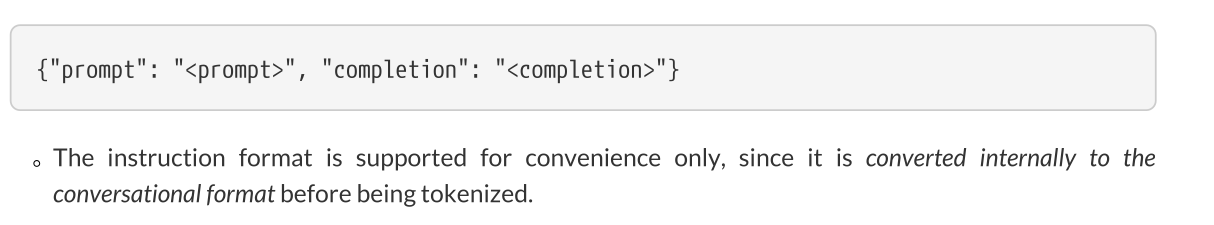

### Behind the scenes

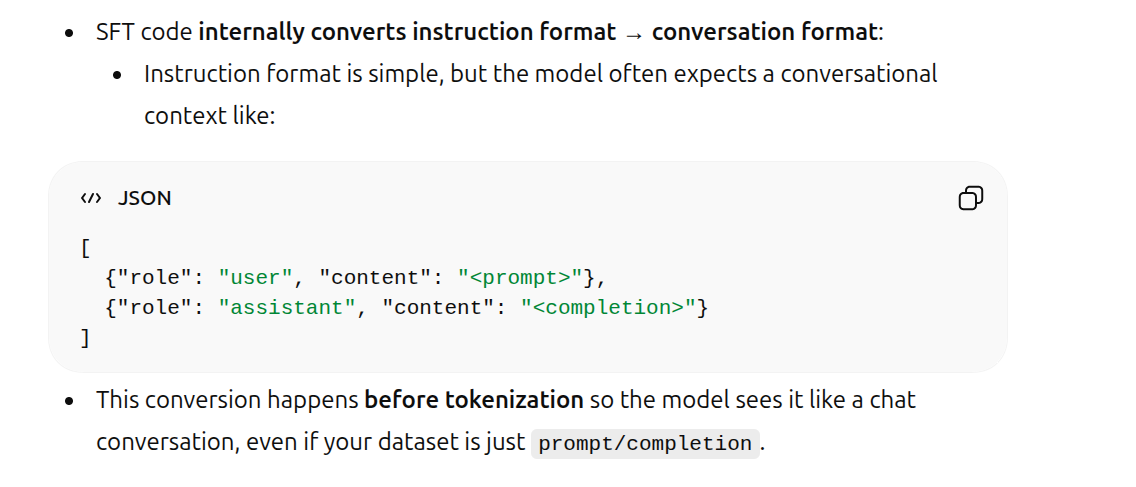

dataset class works in SFT/conversational LLM training

In [15]:
from datasets import Dataset
conversation_ds = Dataset.from_list([{'messages': messages}])


messages is usally list of dicts , each dict representing a turn in the conversation 

In [16]:
messages = [
    {"role": "user", "content": "Hello, translate to Nepali"},
    {"role": "assistant", "content": "नमस्ते"}
]

So the Dataset now has 1 row, and the column messages contains the full conversation

# conversation_ds.features 


.features tells you the schema of the dataset, i.e., column names and types.

In [17]:
conversation_ds.features

{'messages': List({'content': Value('string'), 'role': Value('string')})}

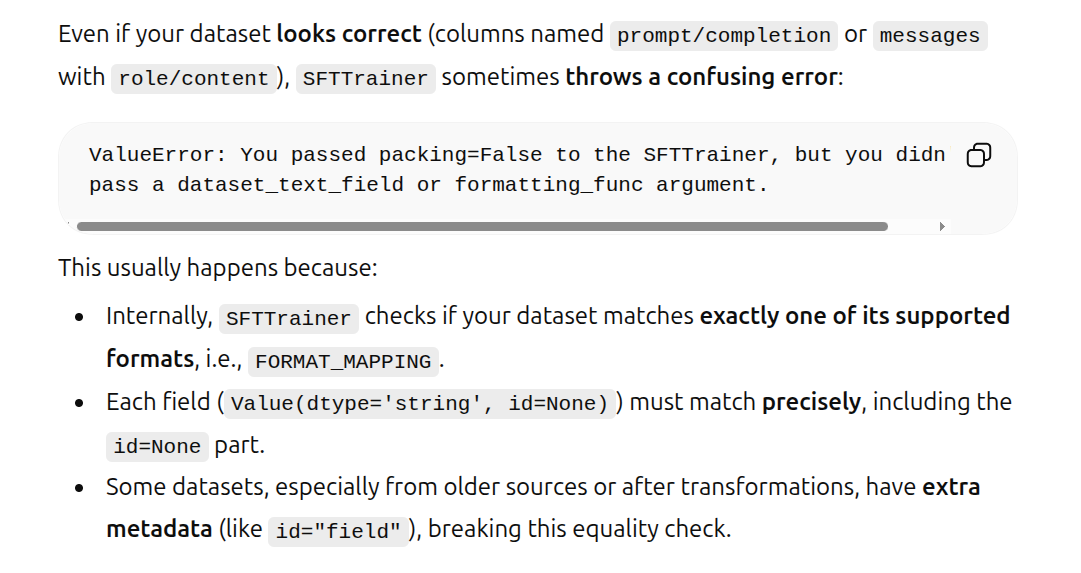

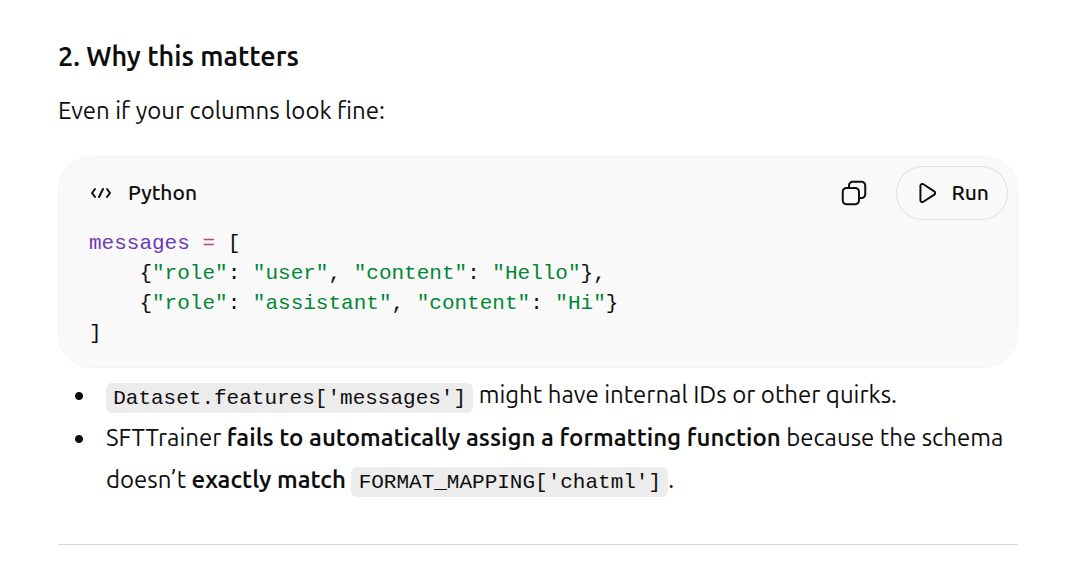

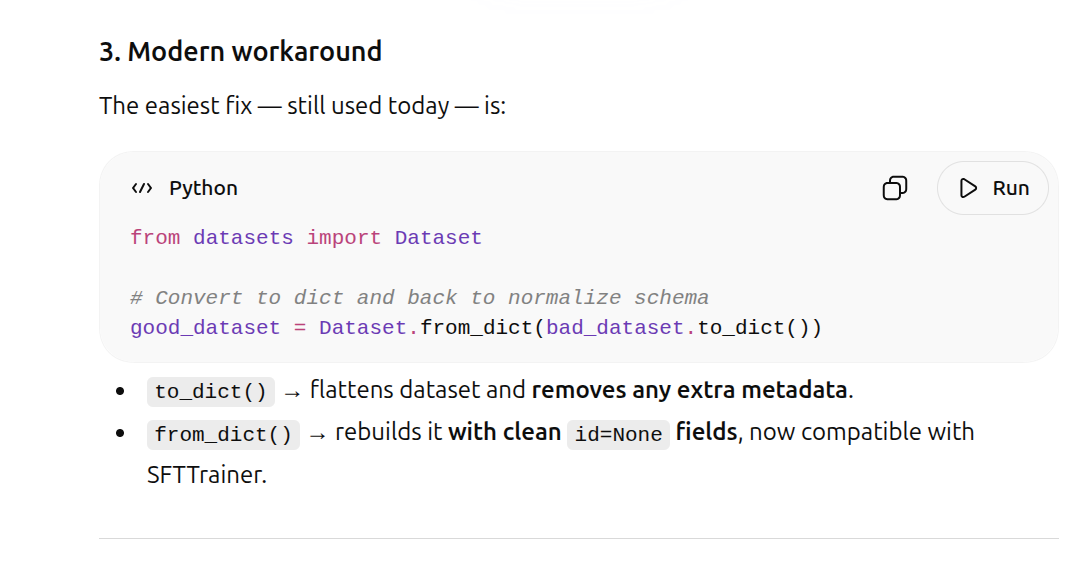

## workflow

### Input data (dataset format)

In [25]:
batch_prompts_completions = {
    "prompt": [
        "What is the capital of Argentina?",
        "What is the capital of the United States?"
    ],
    "completion": [
        "Buenos Aires.",
        "Washington D.C."
    ]
}


prompt → list of user instructions

completion → list of correct responses

# 2. Passed into format_dataset()

In [37]:
from datasets import DatasetDict
from datasets import Dataset 

dataset= Dataset.from_dict(batch_prompts_completions)
dataset

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 2
})

In [52]:
from trl import SFTConfig, SFTTrainer

# 1. Setup Config with the updated argument names
sft_config = SFTConfig(
    output_dir="./output",
    # RENAMED: 'max_seq_length' is now 'max_length'
    max_length=1024,          
    dataset_text_field="text", 
    packing=False,
    completion_only_loss=True, 
    per_device_train_batch_size=4,
)

# 2. Initialize Trainer
trainer = SFTTrainer(
    model=peft_model,
    args=sft_config,
    train_dataset=dataset,
    # RENAMED: 'tokenizer' is now 'processing_class'
    processing_class=tokenizer, 
)

Truncating train dataset: 100%|██████████| 1/1 [00:00<00:00, 246.29 examples/s]


## more on part 2 